# PtO simulation evaluation

This notebook runs a predict-then-optimise expanding-window evaluation on the simulated macro-financial dataset. It does **not** implement black-box or DFL training.

## 1. Imports and setup

In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.exceptions import ConvergenceWarning

SEED = 42
np.random.seed(SEED)

if "seaborn-v0_8-whitegrid" in plt.style.available:
    plt.style.use("seaborn-v0_8-whitegrid")
elif "seaborn-whitegrid" in plt.style.available:
    plt.style.use("seaborn-whitegrid")
else:
    plt.style.use("default")

pd.set_option("display.max_columns", 100)
warnings.filterwarnings("ignore", category=ConvergenceWarning)


def find_repo_root(start=None):
    """Find the repository root from repo root, models/simulation, or a notebook subfolder."""
    start = Path.cwd() if start is None else Path(start).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "models" / "src").exists() and (candidate / "models" / "simulation" / "data").exists():
            return candidate
    raise RuntimeError("Could not find repo root. Set REPO_ROOT manually in this cell.")


REPO_ROOT = find_repo_root()
MODELS_SRC = REPO_ROOT / "models" / "src"
if str(MODELS_SRC) not in sys.path:
    sys.path.insert(0, str(MODELS_SRC))

from capital_allocation_utils import (
    CapitalConfig,
    annualised_pd_from_chargeoff,
    optimise_alpha_from_p,
    optimise_oracle_alpha,
    realised_utility,
)

print(f"Repo root: {REPO_ROOT}")

Repo root: /Users/hannahokeeffe/Documents/Imperial/DFL_New


## 2. Load simulated data

In [2]:
simulation_csv = REPO_ROOT / "models" / "simulation" / "data" / "simulated_variables.csv"
df = pd.read_csv(simulation_csv)
df["DATE"] = pd.to_datetime(df["DATE"])
df = df.sort_values("DATE").reset_index(drop=True)

feature_candidates = [
    "sim_persistent_stress_indicator",
    "sim_noisy_leading_indicator",
    "sim_noisy_leading_indicator_lag1",
    "sim_irrelevant_noise",
]
feature_cols = [col for col in feature_candidates if col in df.columns]
if not feature_cols:
    raise ValueError("No simulated feature columns found in the dataset.")

target_candidates = ["sim_chargeoff", "sim_charge_off_rate", "sim_chargeoff_rate"]
target_source = next((col for col in target_candidates if col in df.columns), None)
if target_source is None:
    raise ValueError(f"Could not find target column. Tried: {target_candidates}")
df["sim_chargeoff"] = pd.to_numeric(df[target_source], errors="coerce")

if "regime" in df.columns:
    df["is_stress"] = df["regime"].astype(int)
elif "regime_label" in df.columns:
    df["is_stress"] = df["regime_label"].str.lower().eq("stress").astype(int)
else:
    df["is_stress"] = 0

if "sim_quarterly_pd" in df.columns and "sim_pd_q" not in df.columns:
    df["sim_pd_q"] = df["sim_quarterly_pd"]
if "sim_annual_pd" in df.columns and "sim_pd_a" not in df.columns:
    df["sim_pd_a"] = df["sim_annual_pd"]
if "sim_oracle_alpha" in df.columns:
    df["alpha_oracle_input"] = df["sim_oracle_alpha"]
elif "alpha_oracle" in df.columns:
    df["alpha_oracle_input"] = df["alpha_oracle"]

df = df.dropna(subset=feature_cols + ["sim_chargeoff"]).reset_index(drop=True)

print(f"Loaded {len(df)} quarterly observations from {simulation_csv.relative_to(REPO_ROOT)}")
print(f"Features: {feature_cols}")
print(f"Target source: {target_source} -> sim_chargeoff")
display(df[["DATE", "is_stress", *feature_cols, "sim_chargeoff"]].head())
display(df[["sim_chargeoff", "is_stress"]].describe().T)

Loaded 144 quarterly observations from models/simulation/data/simulated_variables.csv
Features: ['sim_persistent_stress_indicator', 'sim_noisy_leading_indicator', 'sim_noisy_leading_indicator_lag1', 'sim_irrelevant_noise']
Target source: sim_charge_off_rate -> sim_chargeoff


,DATE,is_stress,sim_persistent_stress_indicator,sim_noisy_leading_indicator,sim_noisy_leading_indicator_lag1,sim_irrelevant_noise,sim_chargeoff
0,1990-06-30,0,-0.541201,-1.253820,-0.010188,-1.369944,0.002646
1,1990-09-30,0,-0.949527,-0.642118,-1.253820,0.432164,0.001424
2,1990-12-31,0,-1.747634,0.061819,-0.642118,-1.023091,0.001550
3,1991-03-31,0,-1.395878,-0.140436,0.061819,0.515283,0.001291
4,1991-06-30,0,-1.560397,-0.470400,-0.140436,-0.099749,0.002376


,count,mean,std,min,25%,50%,75%,max
sim_chargeoff,144.0,0.004622,0.005280,0.000926,0.002136,0.00292,0.004446,0.04
is_stress,144.0,0.152778,0.361029,0.000000,0.000000,0.00000,0.000000,1.00


## 3. Define or import decision functions

The decision layer reuses the existing capital allocation utilities. The sklearn models forecast charge-offs; the forecast is mapped to the same mixture-implied stress probability used by the empirical PtO utilities before optimising alpha.

In [7]:
cap_cfg = CapitalConfig(lgd=0.45, leverage=10)
CHARGEOFF_FLOOR = 0.0005
CHARGEOFF_CAP = 0.0400


def quarterly_pd_from_chargeoff(chargeoff, cfg=cap_cfg):
    pd_q = np.asarray(chargeoff, dtype=float) / cfg.lgd
    return np.clip(pd_q, cfg.pd_floor, cfg.pd_cap)


def annual_pd_from_chargeoff(chargeoff, cfg=cap_cfg):
    return annualised_pd_from_chargeoff(chargeoff, cfg)


def stress_probability_from_chargeoff(chargeoff, cfg=cap_cfg):
    chargeoff = np.asarray(chargeoff, dtype=float)
    denom = cfg.mu_stress - cfg.mu_normal
    if abs(denom) < 1e-12:
        return np.zeros_like(chargeoff)
    return np.clip((chargeoff - cfg.mu_normal) / denom, 0.0, 1.0)


def alpha_from_predicted_chargeoff(pred_chargeoff, cfg=cap_cfg):
    pred_chargeoff = float(np.clip(pred_chargeoff, CHARGEOFF_FLOOR, CHARGEOFF_CAP))
    p_hat = float(stress_probability_from_chargeoff(pred_chargeoff, cfg))
    return optimise_alpha_from_p(p_hat, cfg)


def alpha_from_predicted_pd(pred_pd_q, cfg=cap_cfg):
    pred_chargeoff = float(np.clip(pred_pd_q, cfg.pd_floor, cfg.pd_cap) * cfg.lgd)
    return alpha_from_predicted_chargeoff(pred_chargeoff, cfg)


def oracle_alpha_for_row(row, cfg=cap_cfg):
    # Recompute oracle alpha under the current utility configuration so regret is evaluated consistently.
    return optimise_oracle_alpha(float(row["sim_chargeoff"]), cfg)


def regret_from_realisation(alpha_model, alpha_oracle, realised_chargeoff, cfg=cap_cfg):
    oracle_utility = realised_utility(float(alpha_oracle), float(realised_chargeoff), cfg)
    model_utility = realised_utility(float(alpha_model), float(realised_chargeoff), cfg)
    return oracle_utility - model_utility, model_utility, oracle_utility


# Preserve any oracle column loaded from disk as alpha_oracle_input, but use a freshly
# computed oracle alpha for evaluation with the current CapitalConfig.
df["alpha_oracle"] = [optimise_oracle_alpha(float(c), cap_cfg) for c in df["sim_chargeoff"]]

df["sim_pd_q"] = quarterly_pd_from_chargeoff(df["sim_chargeoff"], cap_cfg)
df["sim_pd_a"] = annual_pd_from_chargeoff(df["sim_chargeoff"], cap_cfg)

display(df[["DATE", "sim_chargeoff", "sim_pd_q", "sim_pd_a", "alpha_oracle"]].head())

,DATE,sim_chargeoff,sim_pd_q,sim_pd_a,alpha_oracle
0,1990-06-30,0.002646,0.005881,0.023316,0.673303
1,1990-09-30,0.001424,0.003164,0.012595,0.761294
2,1990-12-31,0.001550,0.003444,0.013704,0.748044
3,1991-03-31,0.001291,0.002869,0.011429,0.777172
4,1991-06-30,0.002376,0.005280,0.020954,0.687454


## 4. Expanding-window evaluation

In [ ]:
initial_train_window = 120
if len(df) <= initial_train_window:
    initial_train_window = max(40, int(np.floor(0.75 * len(df))))

print(f"Initial training window: {initial_train_window} quarters")
print("Training regime counts:")
display(df.iloc[:initial_train_window]["is_stress"].value_counts().rename(index={0: "normal", 1: "stress"}))
print("Test regime counts:")
display(df.iloc[initial_train_window:]["is_stress"].value_counts().rename(index={0: "normal", 1: "stress"}))


def make_models(seed=SEED):
    return {
        "pto_linear": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LinearRegression()),
        ]),
        "pto_mlp": Pipeline([
            ("scaler", StandardScaler()),
            ("model", MLPRegressor(
                hidden_layer_sizes=(16, 16),
                activation="relu",
                solver="adam",
                alpha=1e-4,
                learning_rate_init=1e-3,
                max_iter=2000,
                random_state=seed,
                early_stopping=False,
            )),
        ]),-
    }


def run_expanding_window(data, feature_cols, initial_window):
    rows = []

    for t in range(initial_window, len(data)):
        train = data.iloc[:t]
        test = data.iloc[[t]]

        x_train = train[feature_cols]
        y_train = train["sim_chargeoff"]
        x_test = test[feature_cols]
        y_test = float(test["sim_chargeoff"].iloc[0])
        alpha_oracle = oracle_alpha_for_row(test.iloc[0], cap_cfg)

        for model_name, model in make_models(seed=SEED + t).items():
            model.fit(x_train, y_train)
            pred_raw = float(model.predict(x_test)[0])
            pred_chargeoff = float(np.clip(pred_raw, CHARGEOFF_FLOOR, CHARGEOFF_CAP))
            pred_pd_q = float(quarterly_pd_from_chargeoff(pred_chargeoff, cap_cfg))
            pred_pd_a = float(annual_pd_from_chargeoff(pred_chargeoff, cap_cfg))
            pred_alpha = alpha_from_predicted_chargeoff(pred_chargeoff, cap_cfg)
            regret, model_utility, oracle_utility = regret_from_realisation(
                pred_alpha,
                alpha_oracle,
                y_test,
                cap_cfg,
            )

            rows.append({
                "DATE": test["DATE"].iloc[0],
                "model": model_name,
                "train_size": t,
                "is_stress": int(test["is_stress"].iloc[0]),
                "regime_label": "stress" if int(test["is_stress"].iloc[0]) == 1 else "normal",
                "actual_chargeoff": y_test,
                "pred_chargeoff_raw": pred_raw,
                "pred_chargeoff": pred_chargeoff,
                "forecast_error": pred_chargeoff - y_test,
                "actual_pd_q": float(test["sim_pd_q"].iloc[0]),
                "actual_pd_a": float(test["sim_pd_a"].iloc[0]),
                "pred_pd_q": pred_pd_q,
                "pred_pd_a": pred_pd_a,
                "alpha_pred": pred_alpha,
                "alpha_oracle": alpha_oracle,
                "realised_utility": model_utility,
                "oracle_utility": oracle_utility,
                "regret": regret,
            })

    results = pd.DataFrame(rows)
    results["cumulative_regret"] = results.groupby("model")["regret"].cumsum()
    return results


results = run_expanding_window(df, feature_cols, initial_train_window)
display(results.head())
display(results.groupby("model")["DATE"].count().rename("n_test_quarters"))

Initial training window: 120 quarters
Training regime counts:


is_stress
normal    101
stress     19
Name: count, dtype: int64

Test regime counts:


is_stress
normal    21
stress     3
Name: count, dtype: int64

,DATE,model,train_size,is_stress,regime_label,actual_chargeoff,pred_chargeoff_raw,pred_chargeoff,forecast_error,actual_pd_q,actual_pd_a,pred_pd_q,pred_pd_a,alpha_pred,alpha_oracle,realised_utility,oracle_utility,regret,cumulative_regret
0,2020-06-30,pto_linear,120,0,normal,0.002691,0.001521,0.001521,-0.001170,0.005980,0.023706,0.003381,0.013456,0.535257,0.671126,1.253225,1.317503,0.064278,0.064278
1,2020-06-30,pto_mlp,120,0,normal,0.002691,0.060511,0.040000,0.037309,0.005980,0.023706,0.088889,0.310895,0.409154,0.671126,1.193567,1.317503,0.123936,0.123936
2,2020-09-30,pto_linear,121,0,normal,0.001345,0.002413,0.002413,0.001068,0.002989,0.011901,0.005361,0.021274,0.535257,0.770475,1.260430,1.374876,0.114446,0.178724
3,2020-09-30,pto_mlp,121,0,normal,0.001345,-0.025211,0.000500,-0.000845,0.002989,0.011901,0.001111,0.004437,0.535257,0.770475,1.260430,1.374876,0.114446,0.238382
4,2020-12-31,pto_linear,122,0,normal,0.001808,0.001770,0.001770,-0.000038,0.004018,0.015976,0.003934,0.015644,0.535257,0.725111,1.257950,1.349444,0.091494,0.270218


model
pto_linear    24
pto_mlp       24
Name: n_test_quarters, dtype: int64

## 5. Metrics

In [9]:
def summarise_model(group):
    mse = mean_squared_error(group["actual_chargeoff"], group["pred_chargeoff"])
    normal_regret = group.loc[group["is_stress"].eq(0), "regret"].mean()
    stress_regret = group.loc[group["is_stress"].eq(1), "regret"].mean()
    return pd.Series({
        "chargeoff_forecast_mse": mse,
        "chargeoff_forecast_rmse": np.sqrt(mse),
        "mean_regret": group["regret"].mean(),
        "median_regret": group["regret"].median(),
        "regret_p95": group["regret"].quantile(0.95),
        "mean_regret_normal": normal_regret,
        "mean_regret_stress": stress_regret,
        "cumulative_regret": group["regret"].sum(),
    })


metrics = results.groupby("model").apply(summarise_model)
display(metrics)

,chargeoff_forecast_mse,chargeoff_forecast_rmse,mean_regret,median_regret,regret_p95,mean_regret_normal,mean_regret_stress,cumulative_regret
model,,,,,,,,
pto_linear,0.000010,0.003230,0.158095,0.077898,0.821347,0.077071,0.725261,3.794269
pto_mlp,0.000381,0.019529,0.178254,0.097097,0.287968,0.091296,0.786958,4.278090


## 6. Plots

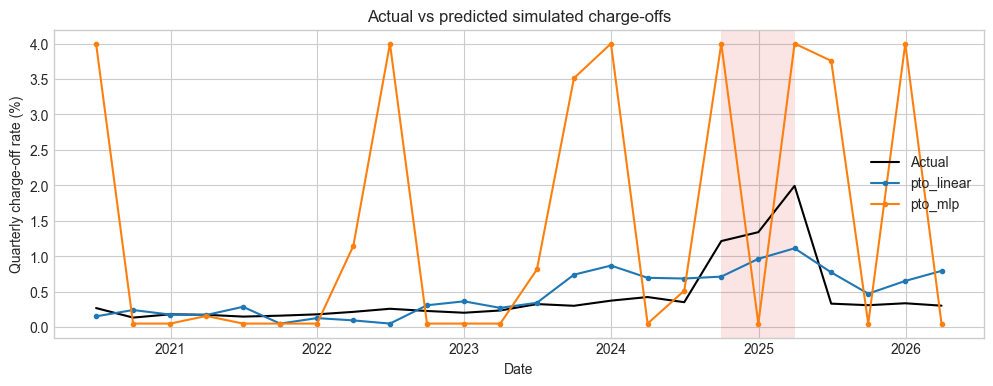

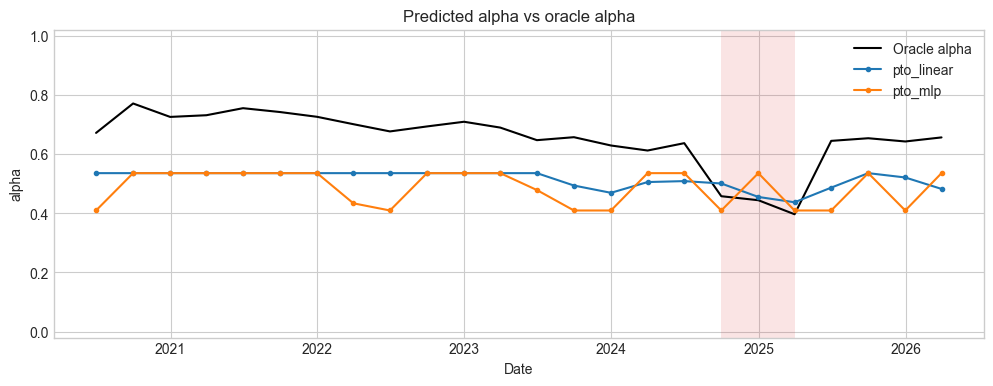

In [10]:
def shade_stress_periods(ax, dates, is_stress, color="tab:red", alpha=0.12):
    dates = pd.Series(pd.to_datetime(dates)).reset_index(drop=True)
    is_stress = pd.Series(is_stress).reset_index(drop=True).astype(bool)
    in_stress = False
    start = None
    for i, stress_now in enumerate(is_stress):
        if stress_now and not in_stress:
            start = dates.iloc[i]
            in_stress = True
        if in_stress and ((not stress_now) or i == len(is_stress) - 1):
            end = dates.iloc[i] if stress_now else dates.iloc[max(i - 1, 0)]
            ax.axvspan(start, end, color=color, alpha=alpha, linewidth=0)
            in_stress = False


test_regimes = df.loc[df["DATE"].isin(results["DATE"].unique()), ["DATE", "is_stress"]]
models = results["model"].unique()

fig, ax = plt.subplots(figsize=(12, 4))
actual = results.drop_duplicates("DATE")
ax.plot(actual["DATE"], 100 * actual["actual_chargeoff"], color="black", label="Actual")
for model_name, group in results.groupby("model"):
    ax.plot(group["DATE"], 100 * group["pred_chargeoff"], marker="o", markersize=3, label=model_name)
shade_stress_periods(ax, test_regimes["DATE"], test_regimes["is_stress"])
ax.set_title("Actual vs predicted simulated charge-offs")
ax.set_ylabel("Quarterly charge-off rate (%)")
ax.set_xlabel("Date")
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(actual["DATE"], actual["alpha_oracle"], color="black", label="Oracle alpha")
for model_name, group in results.groupby("model"):
    ax.plot(group["DATE"], group["alpha_pred"], marker="o", markersize=3, label=model_name)
shade_stress_periods(ax, test_regimes["DATE"], test_regimes["is_stress"])
ax.set_title("Predicted alpha vs oracle alpha")
ax.set_ylabel("alpha")
ax.set_xlabel("Date")
ax.set_ylim(-0.02, 1.02)
ax.legend()
plt.show()

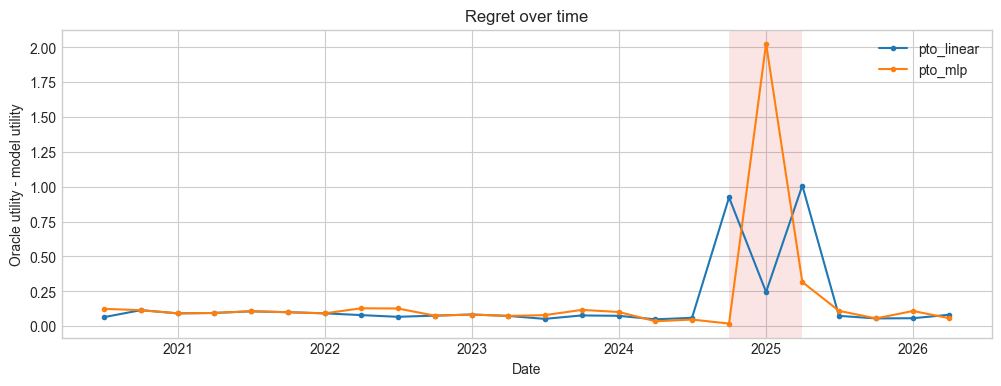

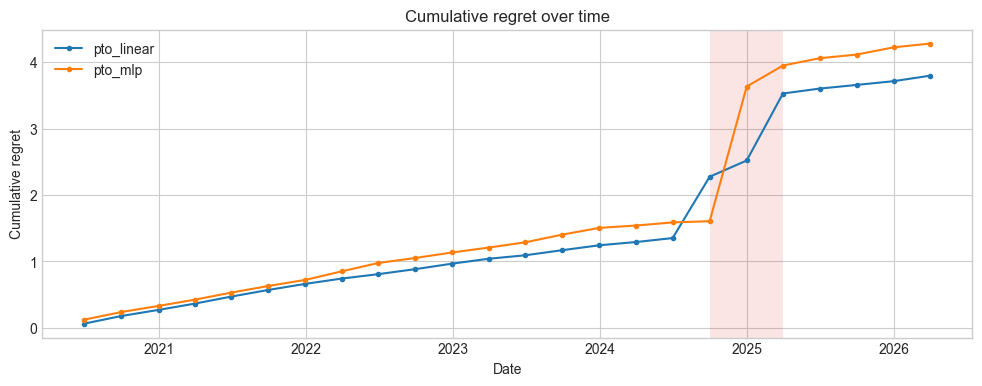

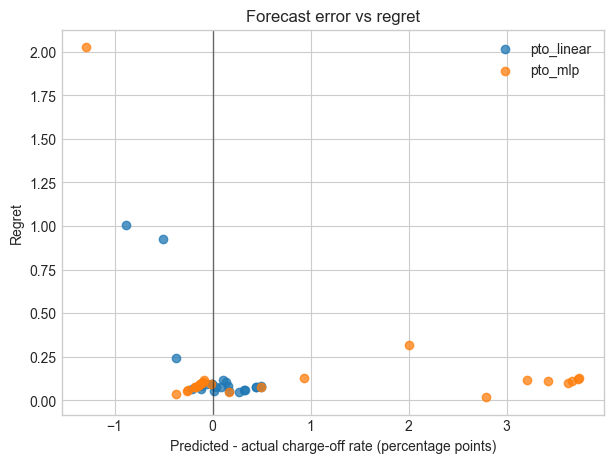

In [11]:
fig, ax = plt.subplots(figsize=(12, 4))
for model_name, group in results.groupby("model"):
    ax.plot(group["DATE"], group["regret"], marker="o", markersize=3, label=model_name)
shade_stress_periods(ax, test_regimes["DATE"], test_regimes["is_stress"])
ax.set_title("Regret over time")
ax.set_ylabel("Oracle utility - model utility")
ax.set_xlabel("Date")
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
for model_name, group in results.groupby("model"):
    ax.plot(group["DATE"], group["cumulative_regret"], marker="o", markersize=3, label=model_name)
shade_stress_periods(ax, test_regimes["DATE"], test_regimes["is_stress"])
ax.set_title("Cumulative regret over time")
ax.set_ylabel("Cumulative regret")
ax.set_xlabel("Date")
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
for model_name, group in results.groupby("model"):
    ax.scatter(100 * group["forecast_error"], group["regret"], alpha=0.75, label=model_name)
ax.axvline(0.0, color="black", linewidth=1, alpha=0.5)
ax.set_title("Forecast error vs regret")
ax.set_xlabel("Predicted - actual charge-off rate (percentage points)")
ax.set_ylabel("Regret")
ax.legend()
plt.show()

## 7. Save results

In [ ]:
results_dir = REPO_ROOT / "models" / "simulation" / "results"
results_dir.mkdir(parents=True, exist_ok=True)

results_csv = results_dir / "pto_simulation_results.csv"
results.to_csv(results_csv, index=False)

print(f"Saved PtO simulation results to: {results_csv.relative_to(REPO_ROOT)}")
display(results.head())